# Ejercicio 2: Clasificación de imágenes con Deep Q-Network

## Pregunta del ejercicio

¿Cómo puede un agente aprender a identificar si una imagen escrita a mano corresponde al número 4 o a cualquier otro dígito usando aprendizaje por refuerzo y una red neuronal?

## ¿Qué busca solucionar?

El código busca resolver un problema de clasificación binaria utilizando imágenes del conjunto de datos MNIST. El agente recibe una imagen de un dígito y debe elegir entre dos acciones:

- `0`: la imagen no es un 4.
- `1`: la imagen sí es un 4.

Después de tomar una decisión, el agente recibe una recompensa de `+1` si acierta o una penalización de `-1` si se equivoca. Mediante muchas iteraciones, ajusta su red neuronal para aprender a distinguir el número 4.

## Temas involucrados

- Inteligencia artificial.
- Aprendizaje por refuerzo.
- Clasificación binaria.
- Conjunto de datos MNIST.
- Procesamiento de imágenes.
- Redes neuronales artificiales.
- Deep Q-Network (DQN).
- Función de pérdida y optimización.
- Algoritmo Adam.
- Política epsilon-greedy.
- Exploración y explotación.
- Entrenamiento y evaluación de un agente.
- Recompensas y penalizaciones.

Iniciando entrenamiento...
Episodio 1000 | Recompensa Promedio (últimos 1000): 0.134 | Epsilon: 0.606
Episodio 2000 | Recompensa Promedio (últimos 1000): 0.446 | Epsilon: 0.368
Episodio 3000 | Recompensa Promedio (últimos 1000): 0.650 | Epsilon: 0.223
Episodio 4000 | Recompensa Promedio (últimos 1000): 0.782 | Epsilon: 0.135
Episodio 5000 | Recompensa Promedio (últimos 1000): 0.812 | Epsilon: 0.082
Episodio 6000 | Recompensa Promedio (últimos 1000): 0.864 | Epsilon: 0.050
Episodio 7000 | Recompensa Promedio (últimos 1000): 0.900 | Epsilon: 0.050
Episodio 8000 | Recompensa Promedio (últimos 1000): 0.856 | Epsilon: 0.050
Episodio 9000 | Recompensa Promedio (últimos 1000): 0.878 | Epsilon: 0.050
Episodio 10000 | Recompensa Promedio (últimos 1000): 0.912 | Epsilon: 0.050
Entrenamiento finalizado.
Mostrando resultados de prueba...
Aciertos en la muestra de los dígitos 0 al 9: 10/10


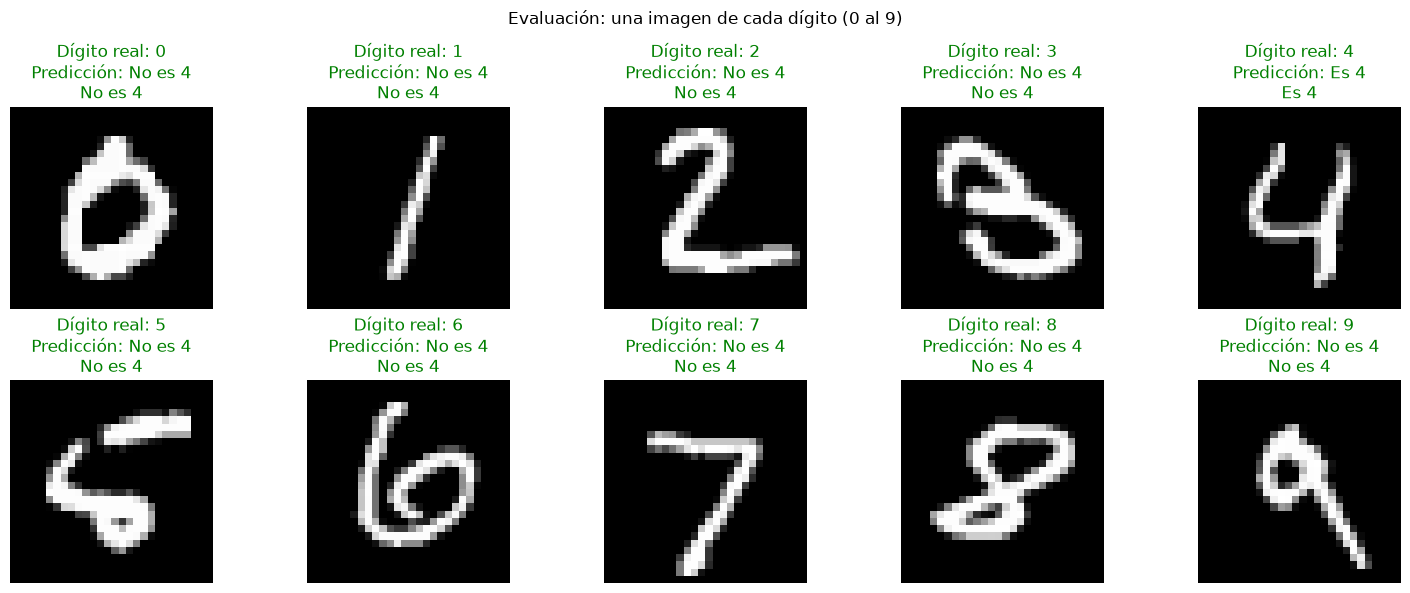

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import random

# ==========================================
# 1. Definición del Entorno (Environment)
# ==========================================
class MNISTEnv:
    def __init__(self, dataset):
        self.dataset = dataset
        self.num_samples = len(dataset)
        
    def reset(self):
        # Elegir una imagen aleatoria
        idx = random.randint(0, self.num_samples - 1)
        img, label = self.dataset[idx]
        
        # El objetivo es 1 si es '4', 0 en caso contrario
        target = 1 if label == 4 else 0
        
        # Aplanar la imagen 28x28 a un vector de 784
        state = img.view(-1)
        return state, target
    
    def step(self, action, target):
        # Recompensa: +1 si acierta, -1 si se equivoca
        if action == target:
            reward = 1.0
        else:
            reward = -1.0
        return reward

# ==========================================
# 2. Definición del Agente (Deep Q-Network)
# ==========================================
class QNetwork(nn.Module):
    def __init__(self):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 2)  # 2 acciones: No es 4 (0) y Es 4 (1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# ==========================================
# 3. Preparación de Datos y Entrenamiento
# ==========================================
def main():
    # Descargar e importar datos
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    env = MNISTEnv(train_dataset)
    q_net = QNetwork()
    optimizer = optim.Adam(q_net.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    # Hiperparámetros de RL
    episodes = 10000  # Número de iteraciones
    epsilon = 1.0     # Tasa de exploración inicial
    epsilon_decay = 0.9995
    epsilon_min = 0.05

    rewards_history = []

    print("Iniciando entrenamiento...")
    for episode in range(episodes):
        state, target = env.reset()
        
        # Política Epsilon-Greedy
        if random.random() < epsilon:
            action = random.randint(0, 1) # Exploración aleatoria
        else:
            with torch.no_grad():
                q_values = q_net(state)
                action = torch.argmax(q_values).item() # Explotación
                
        # Tomar acción y observar recompensa
        reward = env.step(action, target)
        rewards_history.append(reward)
        
        # Actualizar la Q-Network
        q_values = q_net(state)
        target_q_values = q_values.clone().detach()
        target_q_values[action] = reward # Episodio de 1 paso
        
        loss = loss_fn(q_values, target_q_values)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Decaer epsilon
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        
        if (episode + 1) % 1000 == 0:
            avg_reward = np.mean(rewards_history[-1000:])
            print(f"Episodio {episode+1} | Recompensa Promedio (últimos 1000): {avg_reward:.3f} | Epsilon: {epsilon:.3f}")

    print("Entrenamiento finalizado.")

    # ==========================================
    # 4. Evaluación Visual del Agente
    # ==========================================
    print("Mostrando resultados de prueba...")
    q_net.eval()

    # Seleccionar una imagen de cada dígito: 0, 1, 2, ..., 9
    indices_por_digito = []
    for digito in range(10):
        for indice, etiqueta in enumerate(test_dataset.targets):
            if int(etiqueta) == digito:
                indices_por_digito.append(indice)
                break

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()

    aciertos = 0
    for i, indice in enumerate(indices_por_digito):
        state, label = test_dataset[indice]
        target = 1 if label == 4 else 0

        with torch.no_grad():
            q_values = q_net(state.view(-1))
            action = torch.argmax(q_values).item()

        img = state.view(28, 28).numpy()
        pred_text = "Es 4" if action == 1 else "No es 4"
        true_text = "Es 4" if target == 1 else "No es 4"
        correcto = action == target
        aciertos += int(correcto)
        color = "green" if correcto else "red"

        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Dígito real: {label}\nPredicción: {pred_text}\n{true_text}", color=color)
        axes[i].axis('off')

    print(f"Aciertos en la muestra de los dígitos 0 al 9: {aciertos}/10")
    plt.suptitle("Evaluación: una imagen de cada dígito (0 al 9)")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()